## Cerebellar grey matter volume extractor

Using SUITPy

In [1]:
# Import packages
from nilearn import plotting as npl
import SUITPy as suit
import SUITPy.atlas as atlas
import nibabel as nib
import ants
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path # for saving file name

In [2]:
"""
Modified SUITPy.normalization function: added args jac_log = False, jac_geom = True
Make sure to also add the template (in folder "templates")
"""
import sys
sys.path.append('/Users/medha/Desktop/USRI 2026/suitpy edits')

from normalization import normalize # import from above folder

import SUITPy.normalization as modif

modif.normalize = normalize # SUITPy.normalization normalize function now uses local (edited) normalize function

In [3]:
t1_img = 'smarts_cerebellum/anatomicals/CU_2310/W0/CU_2310_W0_T1.nii' # path
gm_img = 'smarts_cerebellum/anatomicals/CU_2310/W0/c1CU_2310_W0_T1.nii' 
file_name = Path(t1_img).stem

In [4]:
# new folder for each individual's outputs
new_path = Path('gmv_results') / file_name
new_path.mkdir(parents = True)

In [5]:
# 1. isolation module

"""
`isolate` function generates an isolation MASK for cerebellum; registration done by function
input: T1-weighted scan
output: cerebellar mask (as ANTsImage)
"""
mask = suit.isolate(t1_img, result_folder = new_path)
mask_path = new_path/f'{file_name}_cerebellum_dseg.nii.gz'

"""
# visualize results
img = nib.load(t1_img)
mask = nib.load(str(mask_path))
npl.plot_roi(mask_img, img)
"""

preprocessing smarts_cerebellum/anatomicals/CU_2310/W0/CU_2310_W0_T1.nii
isolating cerebellum using UNet model
postprocessing
saving results to CU_2310_W0_T1_cerebellum_dseg.nii.gz


'\n# visualize results\nimg = nib.load(t1_img)\nmask = nib.load(str(mask_path))\nnpl.plot_roi(mask_img, img)\n'

In [6]:
# 2. normalization module

"""
Input: cerebellar mask (from isolation); source image
Output: (1) normalized cerebellum: anatomical in SUIT space; (2) deformation field
Normalizes to the SUIT cerebellar template
"""

results = modif.normalize(source_file = t1_img,
                         mask_file = str(mask_path),
                         space = 'SUIT', # SUIT is default
                         write_jacobian_determinant=True, # save jac det
                         write_ants_transform = True, # forward and inverse ANTs transforms
                         write_normalized = True, # save template space
                         result_folder = new_path,
                         jac_log = False,
                         jac_geom = True, # robust to different image orientations (e.g. non-axial)
                         verbose = 1)

Normalizing CU_2310_W0_T1 to tpl-SUIT_T1w.nii.gz
Saving the normalized image into CU_2310_W0_T1_space-SUIT.nii.gz
Saving deformation field into CU_2310_W0_T1_to-SUIT_mode-image_xfm.nii.gz
Saving the  geometric Jacobian determinant to CU_2310_W0_T1_to-SUIT_mode-image_detJ.nii.gz


In [7]:
"""
Reslice module:
`reslice_image` deforms images aligned to indiv anat img into SUIT space
So use the isolation mask (isolation) and deformation file (normalization)
"""

'\nReslice module:\n`reslice_image` deforms images aligned to indiv anat img into SUIT space\nSo use the isolation mask (isolation) and deformation file (normalization)\n'

In [8]:
# 3. reslice image

"""
Input: cerebellar gm (c1), deformation image, cerebellar mask
Output: resliced image
"""
# (anatomical) grey matter in suit space
output_img = suit.reslice_image(source_image = gm_img , # want grey matter mapped from naive space to suit space
                                deformation = results['fwd_deformation'],
                                mask = str(mask_path) # nifti, str
)

nib.save(output_img, new_path/f'output_{file_name}.nii') # grey matter probability

# optional plotting
#npl.plot_anat(output_img, cut_coords=(-1, -58, -36)) # specify 3-dim coordinates


In [ ]:
help(suit.reslice)

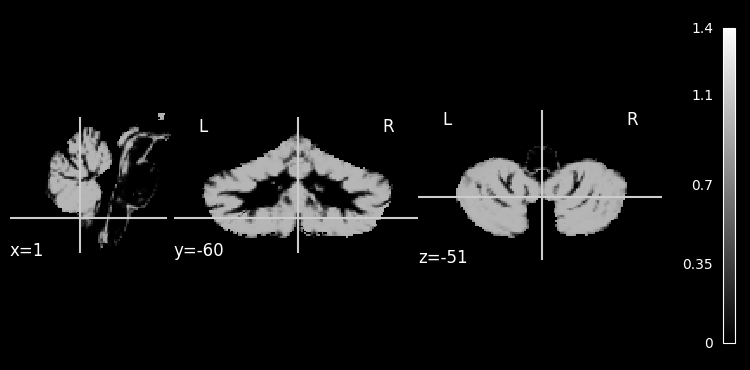

In [10]:
npl.plot_anat(output_img)

In [11]:
# calculate gmv in suit space
voxel_dim = output_img.header.get_zooms()[:3] # voxel volume DIMENSIONS, also check in fsleyes
voxel_vol = np.prod(voxel_dim) # volume of each voxel

# mask GM with isolated cerebellar mask
gm_data = output_img.get_fdata() # grey matter in suit space
jac_det_img = nib.load(results['jacobian_determinant']) # nifti
jac_det = jac_det_img.get_fdata() # numpy array

gmv = gm_data*jac_det*voxel_vol

In [12]:
gmv_img = nib.Nifti1Image(gmv, output_img.affine)
nib.save(gmv_img, new_path/f'gmv_img_{file_name}.nii')

In [13]:
# 4. dataframe for resliced image (choose an atlas)

# in this case, using Nettekoven_2024 with asymmetric 32-region map (for hand function region, M3)
atlas.fetch_atlas('Diedrichsen_2009')
df = atlas.summarize_data(gmv_img, space = 'SUIT', # use same space as normalization
                     stats = ['nanmean'],
                     atlas = 'Diedrichsen_2009', maps = 'atl-Anatom')
df['gmv'] = df['nanmean']*(df['size']/voxel_vol) # total volume = sum of gmv/voxel
 # to get the sum: size is volume of region (mm^3, voxel), so number of voxels is size / voxel volume

#df.rename(columns={'nanmean': 'GM_prob'}, inplace = True)

df['image_name'] = f'gmv_img_{file_name}.nii' # file name for each
#df.drop(columns = 'nanmean', inplace = True)
df

,image,image_name,frame,region,regionname,size,atlas,map,space,nanmean,gmv
0,1,gmv_img_CU_2310_W0_T1.nii,0,1,Left_I_IV,4895.0,Diedrichsen_2009,atl-Anatom,SUIT,0.454875,2226.614337
1,1,gmv_img_CU_2310_W0_T1.nii,0,2,Right_I_IV,5491.0,Diedrichsen_2009,atl-Anatom,SUIT,0.528315,2900.976390
2,1,gmv_img_CU_2310_W0_T1.nii,0,3,Left_V,6052.0,Diedrichsen_2009,atl-Anatom,SUIT,0.506717,3066.650316
3,1,gmv_img_CU_2310_W0_T1.nii,0,4,Right_V,5968.0,Diedrichsen_2009,atl-Anatom,SUIT,0.505148,3014.724681
4,1,gmv_img_CU_2310_W0_T1.nii,0,5,Left_VI,12562.0,Diedrichsen_2009,atl-Anatom,SUIT,0.642923,8076.399964
5,1,gmv_img_CU_2310_W0_T1.nii,0,6,Vermis_VI,2768.0,Diedrichsen_2009,atl-Anatom,SUIT,0.565563,1565.478237
6,1,gmv_img_CU_2310_W0_T1.nii,0,7,Right_VI,11426.0,Diedrichsen_2009,atl-Anatom,SUIT,0.677986,7746.669701
7,1,gmv_img_CU_2310_W0_T1.nii,0,8,Left_CrusI,17767.0,Diedrichsen_2009,atl-Anatom,SUIT,0.432920,7691.694600
8,1,gmv_img_CU_2310_W0_T1.nii,0,9,Vermis_CrusI,27.0,Diedrichsen_2009,atl-Anatom,SUIT,0.162486,4.387134
9,1,gmv_img_CU_2310_W0_T1.nii,0,10,Right_CrusI,17817.0,Diedrichsen_2009,atl-Anatom,SUIT,0.418945,7464.339940


In [14]:
df.to_csv('gmv_results/gmv_atlas.csv', mode = 'a', index = True, header = False) # header only for first run